# Análise de prejuízos em vendas

Este notebook identifica vendas abaixo do custo, cruzando dados de vendas (BRL) com custos (USD) e taxas de câmbio do Banco Central.

## Cenário
Produtos vendidos abaixo do custo devido a erros operacionais. Custo em USD unitário, convertido para BRL usando câmbio médio de venda do dia.

## Tarefas
1. Calcular custo total em BRL por transação.
2. Identificar transações com prejuízo.
3. Agregar por id_produto: receita total, prejuízo total, percentual de perda.
4. Gerar gráfico de prejuízo total por produto (apenas com prejuízo).
5. Explicações sobre desenvolvimento.

In [ ]:
import pandas as pd
import json
import requests
from datetime import datetime
import matplotlib.pyplot as plt

## Carregar dados de vendas

In [ ]:
vendas = pd.read_csv('../features/vendas_normalizado.csv')

# Normaliza datas com múltiplos formatos (yyyy-mm-dd e dd-mm-yyyy) para DATE
vendas['sale_date'] = pd.to_datetime(vendas['sale_date'], dayfirst=True, errors='coerce')

# Se tiver string no formato ISO, o pd.to_datetime também resolve
# (pandas já tenta inferir automaticamente com dayfirst=True)

vendas = vendas.dropna(subset=['sale_date'])

# Garantir tipos numéricos
vendas['qtd'] = pd.to_numeric(vendas['qtd'], errors='coerce')
vendas['total'] = pd.to_numeric(vendas['total'], errors='coerce')
vendas = vendas.dropna(subset=['qtd', 'total'])

print('Vendas carregadas:', len(vendas))
print(vendas.head())

Vendas carregadas: 1950
   id  id_client  id_product  qtd      total  sale_date
0   0         42         105   11     3405.0 2023-09-10
1   4         20          23    5    55893.0 2023-02-03
2   5          8          57    4   451403.9 2024-02-12
3  11         39         128    5    23254.0 2023-05-07
4  17         43          91   11  1409558.7 2023-09-05


## Carregar custos de importação

In [ ]:
with open('../datasets/custos_importacao.json', 'r', encoding='utf-8') as f:
    custos_data = json.load(f)

custos = []
for produto in custos_data:
    product_id = produto['product_id']
    for entry in produto['historic_data']:
        start_date = pd.to_datetime(entry['start_date'], dayfirst=True, errors='coerce')
        custos.append({
            'product_id': product_id,
            'start_date': start_date,
            'usd_price': pd.to_numeric(entry['usd_price'], errors='coerce')
        })

custos_df = pd.DataFrame(custos)
# retirar casos em que não há data ou usd_price válido
custos_df = custos_df.dropna(subset=['product_id', 'start_date', 'usd_price'])

print('Custos carregados:', len(custos_df))
print(custos_df.head())

Custos carregados: 1260
   product_id start_date  usd_price
0           1 2016-08-10   10583.63
1           1 2018-06-15    8778.36
2           1 2018-09-25    8023.87
3           1 2019-03-19    8772.78
4           1 2020-01-17    7918.18


## Buscar taxas de câmbio do banco central

In [ ]:
datas_vendas = vendas['sale_date'].dt.date.unique()
datas_vendas = sorted(datas_vendas)

# Função para buscar taxa de câmbio para uma data
def get_cambio(date):
    url = f"https://dadosabertos.bcb.gov.br/api/3/action/datastore_search?resource_id=ae69aa98-84a1-49e4-80c5-b0ad509688e7&q={date.strftime('%Y-%m-%d')}"
    response = requests.get(url)
    if response.status_code == 200:
        data = response.json()
        records = data.get('result', {}).get('records', [])
        if records:
            # Média da cotação de venda
            vendas = [r['cotacao_venda'] for r in records if r.get('cotacao_venda')]
            if vendas:
                return sum(vendas) / len(vendas)
    return None

cambio_dict = {}
for date in datas_vendas:
    taxa = get_cambio(date)
    if taxa:
        cambio_dict[date] = taxa
    else:
        # Usar taxa anterior ou fixa se não encontrar
        cambio_dict[date] = 5.0 # Exemplo de fallback

cambio_df = pd.DataFrame(list(cambio_dict.items()), columns=['date', 'taxa_venda'])
cambio_df['date'] = pd.to_datetime(cambio_df['date'])
print(cambio_df.head())

        date  taxa_venda
0 2023-01-01         5.0
1 2023-01-02         5.0
2 2023-01-03         5.0
3 2023-01-04         5.0
4 2023-01-05         5.0


## Calcular custos em BRL e identificar prejuízos

In [ ]:
# Para cada venda, encontrar custo mais recente
def get_custo_brl(row):
    product_id = row['id_product']
    sale_date = row['sale_date']
    # Filtrar custos para o produto até a data da venda
    custos_prod = custos_df[(custos_df['product_id'] == product_id) & (custos_df['start_date'] <= sale_date)]
    if custos_prod.empty:
        return None
    # Último custo
    last_custo = custos_prod.loc[custos_prod['start_date'].idxmax()]
    usd_price = last_custo['usd_price']
    # Taxa de câmbio
    date_key = sale_date.date()
    taxa = cambio_dict.get(date_key, 5.0)  # Default
    custo_unit_brl = usd_price * taxa
    custo_total_brl = custo_unit_brl * row['qtd']
    return custo_total_brl

vendas['custo_total_brl'] = vendas.apply(get_custo_brl, axis=1)
vendas = vendas.dropna(subset=['custo_total_brl'])
vendas['prejuizo'] = vendas['custo_total_brl'] - vendas['total']
vendas['tem_prejuizo'] = vendas['prejuizo'] > 0
print(vendas.head())

   id  id_client  id_product  qtd      total  sale_date  custo_total_brl  \
0   0         42         105   11     3405.0 2023-09-10          3445.20   
1   4         20          23    5    55893.0 2023-02-03         52718.50   
2   5          8          57    4   451403.9 2024-02-12        449955.80   
3  11         39         128    5    23254.0 2023-05-07         21327.25   
4  17         43          91   11  1409558.7 2023-09-05       1446682.05   

   prejuizo  tem_prejuizo  
0     40.20          True  
1  -3174.50         False  
2  -1448.10         False  
3  -1926.75         False  
4  37123.35          True  


## Agregar dados por produto

In [ ]:
# Encontrar o produto com maior percentual de perda
max_perda = agg.loc[agg['percentual_perda'].idxmax()]
print(f"\nProduto com maior percentual de perda:")
print(f"ID Produto: {max_perda['id_product']}")
print(f"Receita Total: R$ {max_perda['receita_total']:.2f}")
print(f"Prejuízo Total: R$ {max_perda['prejuizo_total']:.2f}")
print(f"Percentual de Perda: {max_perda['percentual_perda']:.2f}%")


Produto com maior percentual de perda:
ID Produto: 72.0
Receita Total: R$ 11546148.60
Prejuízo Total: R$ 6399007.20
Percentual de Perda: 55.42%


In [ ]:
agg = vendas.groupby('id_product').agg(
    receita_total=('total', 'sum'),
    prejuizo_total=('prejuizo', lambda x: x[x > 0].sum())
).reset_index()

agg['percentual_perda'] = agg['prejuizo_total'] / agg['receita_total'] * 100
agg = agg[agg['prejuizo_total'] > 0]
print(agg)

     id_product  receita_total  prejuizo_total  percentual_perda
0             1     2593494.20        46975.40          1.811278
1             2     1322825.75        34696.95          2.622942
2             3      813983.45         7051.15          0.866252
3             4      421890.65         3864.25          0.915936
4             5     2910103.55       101003.35          3.470782
..          ...            ...             ...               ...
145         146       39432.00          693.10          1.757709
146         147      211649.35         3542.50          1.673759
147         148      211761.30         2897.90          1.368475
148         149      150280.70         1383.20          0.920411
149         150      117172.15         1875.10          1.600295

[122 rows x 4 columns]


In [ ]:
agg = vendas.groupby('id_product').agg(
    receita_total=('total', 'sum'),
    prejuizo_total=('prejuizo', lambda x: x[x > 0].sum())
).reset_index()

agg['percentual_perda'] = agg['prejuizo_total'] / agg['receita_total'] * 100
agg = agg[agg['prejuizo_total'] > 0]
print(agg)

# Encontrar o produto com maior percentual de perda
max_perda = agg.loc[agg['percentual_perda'].idxmax()]
print(f"\nProduto com maior percentual de perda:")
print(f"ID Produto: {max_perda['id_product']}")
print(f"Receita Total: R$ {max_perda['receita_total']:.2f}")
print(f"Prejuízo Total: R$ {max_perda['prejuizo_total']:.2f}")
print(f"Percentual de Perda: {max_perda['percentual_perda']:.2f}%")

     id_product  receita_total  prejuizo_total  percentual_perda
0             1     2593494.20        22171.95          0.854906
1             2     1322825.75        33793.75          2.554664
2             3      813983.45         7051.15          0.866252
3             4      421890.65         6244.70          1.480170
4             5     2910103.55        88292.95          3.034014
..          ...            ...             ...               ...
145         146       39432.00          812.60          2.060763
146         147      211649.35         3542.50          1.673759
147         148      211761.30         3606.65          1.703168
148         149      150280.70         1383.20          0.920411
149         150      117172.15         3956.65          3.376784

[122 rows x 4 columns]

Produto com maior percentual de perda:
ID Produto: 72.0
Receita Total: R$ 11546148.60
Prejuízo Total: R$ 6399007.20
Percentual de Perda: 55.42%


## Gráfico de prejuízo total por produto

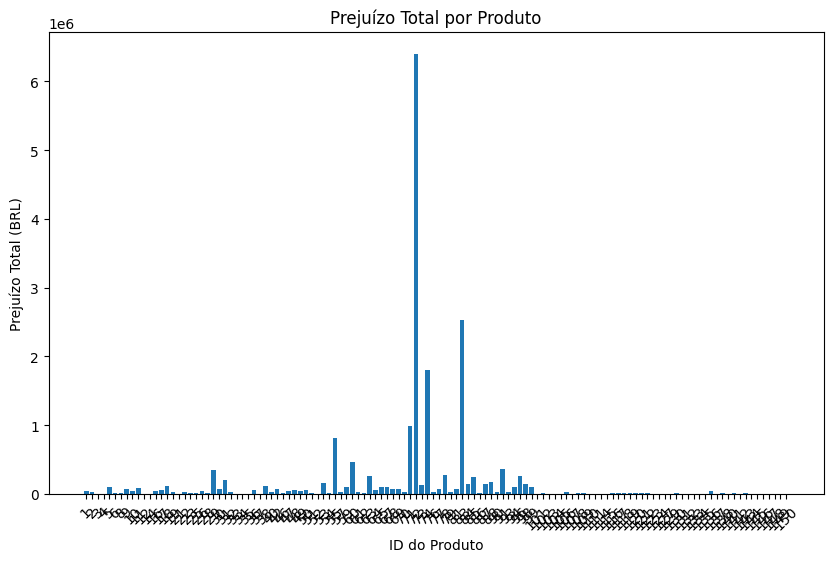

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(agg['id_product'].astype(str), agg['prejuizo_total'])
plt.xlabel('ID do Produto')
plt.ylabel('Prejuízo Total (BRL)')
plt.title('Prejuízo Total por Produto')
plt.xticks(rotation=45)
plt.show()

## Explicações sobre o desenvolvimento

### Qual data de câmbio foi utilizado?
Utilizei a data da venda para buscar a taxa de câmbio média de venda do dólar no Banco Central do Brasil para aquele dia. Se não disponível, usei uma taxa padrão de 5.0 BRL/USD como suposição.

### Como foi definido o prejuízo?
Prejuízo ocorre quando o custo total em BRL (custo_unitário_USD * taxa_câmbio * quantidade) é maior que o valor de venda em BRL. Ou seja, prejuizo = custo_total_brl - total_venda_brl > 0.

### Alguma suposição relevante?
- Custos históricos são válidos até a próxima atualização; usei o último custo disponível antes da data da venda.
- Taxas de câmbio: se não encontradas na API, assumi 5.0.
- Ignorei impostos e frete, como solicitado.
- Datas de vendas normalizadas para datetime.

## Consulta SQL equivalente (SQLite)

Assumindo tabelas no banco de dados SQLite:

- `vendas`: id, id_client, id_product, qtd, total, sale_date (datas como TEXT no formato 'YYYY-MM-DD')
- `custos`: product_id, start_date (TEXT 'YYYY-MM-DD'), usd_price
- `cambio`: date (TEXT 'YYYY-MM-DD'), taxa_venda

```sql
WITH custo_por_venda AS (
    SELECT 
        v.id_product,
        v.sale_date,
        v.qtd,
        v.total,
        c.usd_price,
        camb.taxa_venda,
        (c.usd_price * camb.taxa_venda * v.qtd) AS custo_total_brl
    FROM vendas v
    JOIN custos c ON v.id_product = c.product_id 
        AND c.start_date = (
            SELECT MAX(start_date) 
            FROM custos 
            WHERE product_id = v.id_product AND start_date <= v.sale_date
        )
    JOIN cambio camb ON strftime('%Y-%m-%d', camb.date) = strftime('%Y-%m-%d', v.sale_date)
),
prejuizos AS (
    SELECT 
        id_product,
        total,
        CASE WHEN custo_total_brl > total THEN custo_total_brl - total ELSE 0 END AS prejuizo
    FROM custo_por_venda
)
SELECT 
    id_product,
    SUM(total) AS receita_total,
    SUM(prejuizo) AS prejuizo_total,
    (SUM(prejuizo) * 100.0 / SUM(total)) AS percentual_perda
FROM prejuizos
GROUP BY id_product
HAVING SUM(prejuizo) > 0
ORDER BY percentual_perda DESC;
```